<a href="https://colab.research.google.com/github/NoorullahDev/laptop-price-predictor/blob/main/laptop_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import pickle

# 1. Data Cleaning (Safe way to handle multiple runs)
if df['Ram'].dtype == object:
    df['Ram'] = df['Ram'].str.replace('GB','').astype(int)

# 2. Label Encoding
le_company = LabelEncoder()
df['Company'] = le_company.fit_transform(df['Company'])

le_type = LabelEncoder()
df['TypeName'] = le_type.fit_transform(df['TypeName'])

le_cpu = le_cpu = LabelEncoder()
df['Cpu'] = le_cpu.fit_transform(df['Cpu'])

le_gpu = LabelEncoder()
df['Gpu'] = le_gpu.fit_transform(df['Gpu'])

# 3. Training
X = df[['Company', 'TypeName', 'Ram', 'Cpu', 'Gpu']]
y = df['Price_euros']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=2)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Success! Accuracy: {model.score(X_test, y_test)*100:.2f}%")

# 4. Save everything in one file
data = {
    "model": model,
    "le_company": le_company,
    "le_type": le_type,
    "le_cpu": le_cpu,
    "le_gpu": le_gpu
}

with open('laptop_model.pkl', 'wb') as f:
    pickle.dump(data, f)

Success! Accuracy: 53.40%


In [ ]:
# 'Ram' column se 'GB' hatayein aur number banayein
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)

# 'Weight' column se 'kg' hatayein aur float banayein
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

# Check karein ke ab numbers nazar aa rahe hain
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Hum input (X) mein 'Ram' rakhenge aur target (y) mein 'Price_euros'
X = df[['Ram']]
y = df['Price_euros']

# Data ko Train aur Test mein divide karein (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model banayein aur Train karein
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


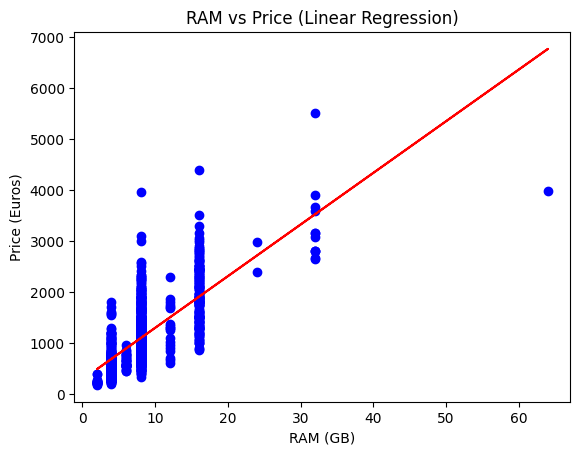

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_train, y_train, color='blue') # Asli data points
plt.plot(X_train, model.predict(X_train), color='red') # Regression Line
plt.title('RAM vs Price (Linear Regression)')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (Euros)')
plt.show()

In [ ]:
import pickle
# Ye line aapki 'laptop_model.pkl' file bana degi
pickle.dump(model, open('laptop_model.pkl', 'wb'))

In [ ]:
# Ye cell run karne se 2 files ban jayengi
app_code = """
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open('laptop_model.pkl', 'rb'))

st.title("💻 Laptop Price Predictor")
st.write("Project by: Noor Ullah")

ram = st.number_input("Enter RAM (GB)", min_value=2, max_value=64, value=8)

if st.button("Predict Price"):
    prediction = model.predict([[ram]])
    st.success(f"Estimated Price: {prediction[0]:.2f} Euros")
"""

with open('app.py', 'w') as f:
    f.write(app_code)

with open('requirements.txt', 'w') as f:
    f.write("streamlit\\npandas\\nscikit-learn\\nnumpy")

print("Dono files tayyar hain! Ab folder se download kar lein.")

Dono files tayyar hain! Ab folder se download kar lein.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import pickle

# 1. Load Data
df = pd.read_csv('laptop_price.csv', encoding='latin-1')

# 2. Cleaning
df['Ram'] = df['Ram'].str.replace('GB','').astype(int)

# 3. Alag Alag Encoders (Ye sabse zaroori hai)
le_company = LabelEncoder()
df['Company'] = le_company.fit_transform(df['Company'])

le_type = LabelEncoder()
df['TypeName'] = le_type.fit_transform(df['TypeName'])

le_cpu = LabelEncoder()
df['Cpu'] = le_cpu.fit_transform(df['Cpu'])

le_gpu = LabelEncoder()
df['Gpu'] = le_gpu.fit_transform(df['Gpu'])

# 4. Training
X = df[['Company', 'TypeName', 'Ram', 'Cpu', 'Gpu']]
y = df['Price_euros']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=2)
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Save EVERYTHING in one dictionary
# Is dictionary mein encoders save karna lazmi hai warna names nahi aayenge
data_to_save = {
    "model": model,
    "le_company": le_company,
    "le_type": le_type,
    "le_cpu": le_cpu,
    "le_gpu": le_gpu
}

with open('laptop_model.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print("Success! Nayi file 'laptop_model.pkl' download kar ke GitHub par upload karein.")

Success! Nayi file 'laptop_model.pkl' download kar ke GitHub par upload karein.
